# Nullstellen

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize

## Mehrere Nullstellen

Wie kann man effizient nach mehreren Nullstellen in einem Intervall suchen? Es gibt verschiedene Möglichkeiten

1. Newton: Man benutzt viele verschiedene Startwerte verteilt über das Intervall.
2. Bisektion: Man unterteilt das Intervall in viele kleine Subintervalle und sucht dann in allen Intervallen, in dennen es einen Vorzeichenwechsel gibt.

In beiden Fällen gibt es keine Garantie, dass man alle Nullstellen findet. Doch je mehr Subintervalle bzw. Startwerte man benutzt, desto höher ist die Wahrscheinlichkeit, alle Nullstellen zu finden.

Wir schauen uns die beiden Methoden an einem konkreten Beispiel an.

### Beispielfunktion

Wir konstruieren ein Polynom mit vielen zufällig erzeugten Nullstellen:

$$
f(x) = \prod_{i=1}^{20} (x - r_i)
$$

wobei $r_i\in[-10,10]$ zufällig erzeugt werden.

In [2]:
n_roots = 10
a, b = -10, 10
rng = np.random.default_rng(seed=42)
r = np.sort(rng.uniform(a, b, size=n_roots))
r

array([-8.11645304, -7.43772735, -1.2224312 , -0.99228124,  3.94736058,
        5.22279404,  5.47912097,  5.72128611,  7.1719584 ,  9.51244703])

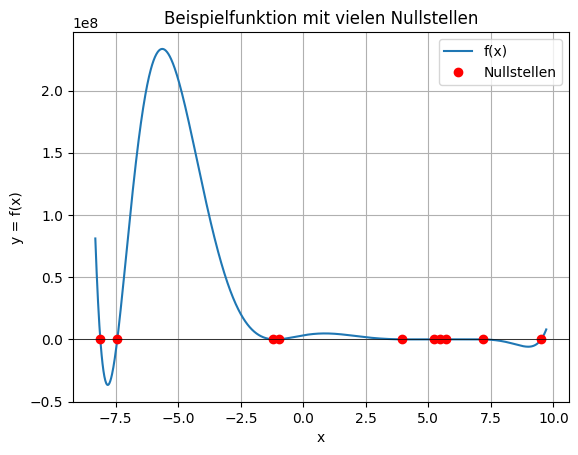

In [3]:
def f(x):
    y = np.ones_like(x)
    for root in r:
        y *= x - root
    return y


x = np.linspace(r.min() - 0.2, r.max() + 0.2, 1000)
plt.plot(x, f(x), label="f(x)")
plt.plot(r, np.zeros_like(r), "ro", label="Nullstellen")
plt.axhline(0, color="black", lw=0.5)
plt.title("Beispielfunktion mit vielen Nullstellen")
plt.xlabel("x")
plt.ylabel("y = f(x)")
plt.grid()
plt.legend()
plt.show()

### 1. Newton mit vielen Startwerten

In [4]:
def find_roots_startpoints_newton(f, a, b, n_points, tol=1e-8, maxiter=1000, **kwargs):
    # Startpunkte gleichmässig über das Intervall verteilen
    x0 = np.linspace(a, b, n_points)
    # Für jeden Startpunkt die Nullstelle mit Newtons Methode suchen
    results = optimize.newton(f, x0, tol=tol, maxiter=maxiter, **kwargs)
    # Duplikate entfernen, da mehrere Startpunkte zur selben Nullstelle konvergieren können
    roots = []
    for root in results:
        if not any(np.isclose(root, roots, atol=tol)):
            roots.append(root)
    return np.array(roots)


find_roots_startpoints_newton(f, a, b, 100, maxiter=1000, tol=1e-10)

/var/folders/p7/c2v89_m12k7dbrfs0m28h1640000gr/T/ipykernel_67319/3359796950.py:5: RuntimeWarning: some failed to converge after 1000 iterations
  results = optimize.newton(f, x0, tol=tol, maxiter=maxiter, **kwargs)


array([-8.11645304, -7.43772735, -1.2224312 , -5.71700529, -5.71618092,
       -5.71756869, 24.35759989, -1.11112553, -0.99228124,  3.94736058,
        7.1719584 ,  0.90824391,  5.72128611,  5.22279404,  5.47912097,
        8.9899672 ,  9.51244703])

In [5]:
def find_roots_startpoints_root_scalar(
    f, a, b, n_points, tol=1e-8, maxiter=1000, **kwargs
):
    # Startpunkte gleichmässig über das Intervall verteilen
    x0 = np.linspace(a, b, n_points)
    # Für jeden Startpunkt die Nullstelle bestimmen
    results = [
        optimize.root_scalar(f, x0=x, xtol=tol, maxiter=maxiter, **kwargs) for x in x0
    ]
    # Nur konvergente Ergebnisse behalten
    converged_results = [res.root for res in results if res.converged]
    # Duplikate entfernen, da mehrere Startpunkte zur selben Nullstelle konvergieren können
    roots = []
    for root in converged_results:
        if not any(np.isclose(root, roots, atol=tol)):
            roots.append(root)
    return np.sort(roots)


find_roots_startpoints_root_scalar(f, a, b, 100, maxiter=1000, tol=1e-10)

array([-8.11645304, -7.43772735, -1.2224312 , -0.99228124,  3.94736058,
        5.22279404,  5.47912097,  5.72128611,  7.1719584 ,  9.51244703])

### 2. Bisektion mit vielen Subintervallen

In [6]:
def find_roots_subintervals(f, a, b, n_subintervals):
    boundaries = np.linspace(a, b, n_subintervals + 1)
    roots = []
    for i in range(n_subintervals):
        lower, upper = boundaries[i], boundaries[i + 1]
        if f(lower) * f(upper) < 0:  # Vorzeichenwechsel
            result = optimize.root_scalar(f, bracket=[lower, upper])
            if result.converged:
                roots.append(result.root)
    return np.array(roots)


find_roots_subintervals(f, a, b, 100)

array([-8.11645304, -7.43772735, -1.2224312 , -0.99228124,  3.94736058,
        5.22279404,  5.47912097,  5.72128611,  7.1719584 ,  9.51244703])